# Soal Nomor 4 — Diferensiasi & Integrasi Numerik

**Masalah A:** Hitung laju perubahan produksi per bulan untuk 2020 dan 2021 menggunakan **Diferensiasi Numerik**.
Cari bulan dengan kenaikan tertajam dan penurunan tertajam.

**Masalah B:** Hitung total produksi Jan 2018 - Des 2023 menggunakan **Integrasi Numerik**,
bandingkan dengan jumlah aktual data, jelaskan keakuratannya.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
data = pd.read_excel('aol_data.xlsx')
x = np.arange(1, 145) 
y = data.values[0]       

a3, a2, a1, a0 = np.polyfit(x, y, 3)
model_polinomial = np.poly1d([a3, a2, a1, a0])

print(f"Model produksi: P(t) = {a3:.4f}t^3 + {a2:.4f}t^2 + {a1:.4f}t + {a0:.4f}")

Model produksi: P(t) = 0.0039t^3 + -0.1344t^2 + 47.2236t + 1748.5067


## Bagian A — Diferensiasi Numerik

**Tujuan:** Hitung laju perubahan produksi per bulan untuk 2020 & 2021.

**Metode:** *Central Difference*

**Alasan:** Metode Central Difference menggunakan data sebelum dan sesudah titik yang dihitung, sehingga memberikan hasil yang lebih akurat dibanding forward atau backward difference. Laju perubahan pada titik pertama dan terakhir dihitung dengan forward/backward difference karena tidak memiliki data di kedua sisi.

In [10]:
produksi_per_bulan = []
for i in range(0, 144, 2):
    produksi_per_biweekly = y[i] + y[i+1]
    produksi_per_bulan.append(produksi_per_biweekly)

total_bulan = len(produksi_per_bulan)
indeks_bulan = np.arange(total_bulan) 

laju_perubahan = np.zeros(total_bulan)

laju_perubahan[0] = produksi_per_bulan[1] - produksi_per_bulan[0]

for b in range(1, total_bulan - 1):
    laju_perubahan[b] = (produksi_per_bulan[b+1] - produksi_per_bulan[b-1]) / 2

laju_perubahan[-1] = produksi_per_bulan[-1] - produksi_per_bulan[-2]

### Analisis Tahun 2020

Indeks ke-24 sampai 35 dalam array = Jan 2020 sampai Des 2020.


In [11]:
print("TAHUN 2020")
print()

daftar_bulan = ["Jan","Feb","Mar","Apr","Mei","Jun", "Jul","Agu","Sep","Okt","Nov","Des"]

print(f"{'Bulan':<15} {'Produksi':<15} {'Laju':<15}")
print("-" * 45)

for b in range(24, 36):
    nama = f"{daftar_bulan[b % 12]} 2020"
    print(f"{nama:<15} {produksi_per_bulan[b]:<15.3f} {laju_perubahan[b]:<15.3f}")

laju_2020 = laju_perubahan[24:36]
idx_2020 = range(24, 36)

idx_naik_2020 = np.argmax(laju_2020)
idx_turun_2020 = np.argmin(laju_2020)

print(f"\nKenaikan tertajam 2020: {daftar_bulan[idx_2020[idx_naik_2020] % 12]} 2020")
print(f"Penurunan tertajam 2020: {daftar_bulan[idx_2020[idx_turun_2020] % 12]} 2020")

TAHUN 2020

Bulan           Produksi        Laju           
---------------------------------------------
Jan 2020        8638.000        589.000        
Feb 2020        9257.000        245.500        
Mar 2020        9129.000        327.500        
Apr 2020        9912.000        102.000        
Mei 2020        9333.000        137.000        
Jun 2020        10186.000       240.000        
Jul 2020        9813.000        116.000        
Agu 2020        10418.000       469.500        
Sep 2020        10752.000       278.000        
Okt 2020        10974.000       346.000        
Nov 2020        11444.000       624.500        
Des 2020        12223.000       593.500        

Kenaikan tertajam 2020: Nov 2020
Penurunan tertajam 2020: Apr 2020


### Analisis Tahun 2021

Indeks ke-36 sampai 47 dalam array = Jan 2021 sampai Des 2021.


In [12]:
print("TAHUN 2021")
print()

print(f"{'Bulan':<15} {'Produksi':<15} {'Laju':<15}")
print("-" * 45)

for b in range(36, 48):
    nama = f"{daftar_bulan[b % 12]} 2021"
    print(f"{nama:<15} {produksi_per_bulan[b]:<15.3f} {laju_perubahan[b]:<15.3f}")

rate_2021 = laju_perubahan[36:48]
idx_2021 = range(36, 48)

idx_naik_2021 = np.argmax(rate_2021)
idx_turun_2021 = np.argmin(rate_2021)

print(f"\nKenaikan tertajam 2021: {daftar_bulan[idx_2021[idx_naik_2021] % 12]} 2021")
print(f"Penurunan tertajam 2021: {daftar_bulan[idx_2021[idx_turun_2021] % 12]} 2021")

TAHUN 2021

Bulan           Produksi        Laju           
---------------------------------------------
Jan 2021        12631.000       120.000        
Feb 2021        12463.000       72.000         
Mar 2021        12775.000       382.500        
Apr 2021        13228.000       371.000        
Mei 2021        13517.000       -25.000        
Jun 2021        13178.000       450.500        
Jul 2021        14418.000       1103.500       
Agu 2021        15385.000       776.500        
Sep 2021        15971.000       409.000        
Okt 2021        16203.000       66.500         
Nov 2021        16104.000       549.000        
Des 2021        17301.000       632.500        

Kenaikan tertajam 2021: Jul 2021
Penurunan tertajam 2021: Mei 2021


## Bagian B — Integrasi Numerik

**Tujuan:** Hitung total produksi Jan 2018 - Des 2023, bandingkan dengan jumlah aktual.

**Metode 1:** Trapezoidal Rule

**Alasan:** Trapezoidal Rule mengaproksimasi luas area di bawah kurva dengan membagi area menjadi trapesium-trapesium. Sederhana dan efektif untuk data diskrit.

**Metode 2:** Simpson's 1/3 Rule

**Alasan:** Simpson's 1/3 Rule mengaproksimasi area menggunakan polinomial derajat 2 (parabola) untuk setiap dua interval berurutan. Umumnya lebih akurat untuk fungsi kontinu, tetapi data biweekly yang diskrit bisa mempengaruhi akurasinya.

In [13]:
total_aktual = sum(y)
print(f"\nJumlah aktual (sum data):     {total_aktual:,.3f} tas")

jarak = 1
total_trapezoidal = (jarak / 2) * (y[0] + 2 * sum(y[1:-1]) + y[-1])
print(f"Trapezoidal Rule:             {total_trapezoidal:,.3f} tas")

total_simpson = (jarak / 3) * (y[0] + y[-1] + 4 * sum(y[1:-1:2]) + 2 * sum(y[2:-1:2]))
print(f"Simpson's 1/3 Rule:           {total_simpson:,.3f} tas")

error_trapesium = abs(total_trapezoidal - total_aktual)
error_simpson = abs(total_simpson - total_aktual)

print(f"\nError Trapezoidal:   {error_trapesium:,.3f} ({error_trapesium/total_aktual*100:.3f}%)")
print(f"Error Simpson:       {error_simpson:,.3f} ({error_simpson/total_aktual*100:.3f}%)")


Jumlah aktual (sum data):     1,030,745.000 tas
Trapezoidal Rule:             1,020,969.000 tas
Simpson's 1/3 Rule:           1,013,143.333 tas

Error Trapezoidal:   9,776.000 (0.948%)
Error Simpson:       17,601.667 (1.708%)


## Visualisasi


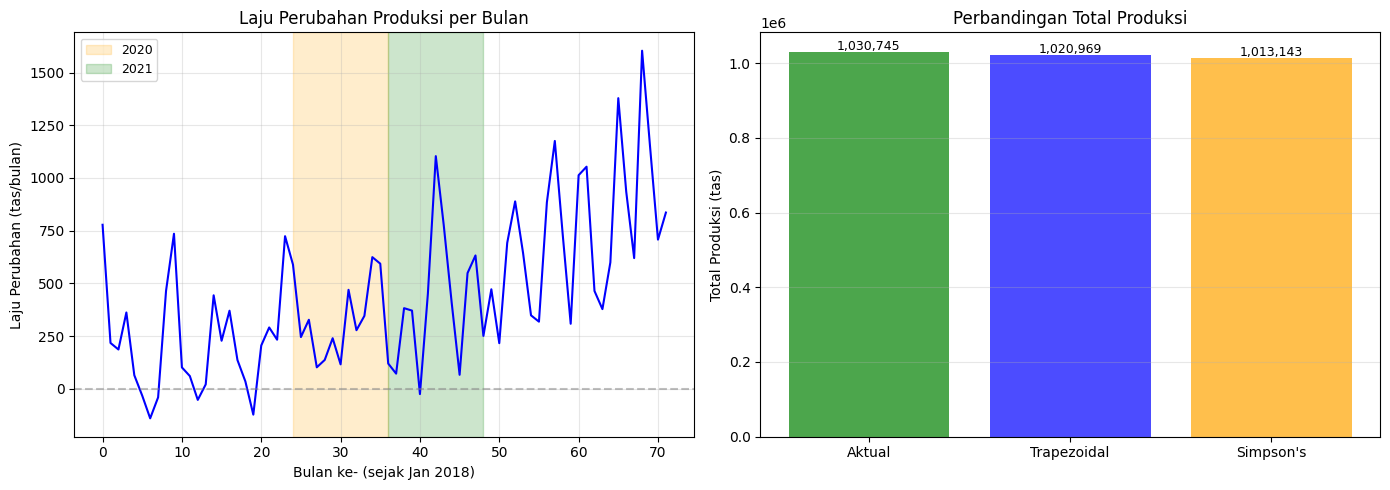

In [14]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(indeks_bulan, laju_perubahan, 'b-', linewidth=1.5)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvspan(24, 36, alpha=0.2, color='orange', label='2020')
plt.axvspan(36, 48, alpha=0.2, color='green', label='2021')
plt.xlabel('Bulan ke- (sejak Jan 2018)')
plt.ylabel('Laju Perubahan (tas/bulan)')
plt.title('Laju Perubahan Produksi per Bulan')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
metode = ['Aktual', 'Trapezoidal', "Simpson's"]
nilai = [total_aktual, total_trapezoidal, total_simpson]
warna = ['green', 'blue', 'orange']
plt.bar(metode, nilai, color=warna, alpha=0.7)
plt.ylabel('Total Produksi (tas)')
plt.title('Perbandingan Total Produksi')
plt.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(nilai):
    plt.text(i, v + 5000, f'{v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()